In [1]:
import numpy as np
import seaborn as sns
import os
import pandas as pd
import matplotlib.pyplot as plt

# Data (3 sources de données: 2 datasets de kaggle et FRED)

## bankruptcy dataset

In [2]:
data=pd.read_csv('/kaggle/input/datasets/utkarshx27/american-companies-bankruptcy-prediction-dataset/american_bankruptcy.csv') 

In [3]:
data.head()

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


## macro-economic factors dataset

In [6]:
data_macro=pd.read_csv('/kaggle/input/datasets/sagarvarandekar/macroeconomic-factors-affecting-us-housing-prices/DATA.csv')

In [7]:
data_macro

,DATE,UNRATE(%),CONSUMER CONF INDEX,PPI-CONST MAT.,CPIALLITEMS,INFLATION(%),MORTGAGE INT. MONTHLY AVG(%),MED HOUSEHOLD INCOME,CORP. BOND YIELD(%),MONTHLY HOME SUPPLY,% SHARE OF WORKING POPULATION,GDP PER CAPITA,QUARTERLY REAL GDP,QUARTERLY GDP GROWTH RATE (%),CSUSHPISA
0,01-05-2022,3.6,106.4,352.857,123.322800,8.581511,5.2300,NaN,4.13,8.4,NaN,74737,19699.465,-0.144227,120.724
1,01-04-2022,3.6,107.3,343.730,121.978170,8.258629,4.9825,NaN,3.76,8.4,NaN,74737,19699.465,-0.144227,121.813
2,01-03-2022,3.6,107.2,345.852,121.301004,8.542456,4.1720,NaN,3.43,7.0,NaN,73289,19727.918,-0.395692,122.888
3,01-02-2022,3.8,110.5,343.583,119.702806,7.871064,3.7625,NaN,3.25,6.0,NaN,73289,19727.918,-0.395692,123.831
4,01-01-2022,4.0,113.8,345.742,118.619339,7.479872,3.4450,NaN,2.93,5.7,NaN,73289,19727.918,-0.395692,124.780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,01-09-2002,5.7,94.5,145.400,76.365830,1.514302,6.0925,42409.0,6.15,3.9,66.593595,38099,13531.741,0.403529,284.767
237,01-08-2002,5.7,97.4,145.100,76.239257,1.802817,6.2900,42409.0,6.37,4.0,66.593595,38099,13531.741,0.403529,290.371
238,01-07-2002,5.8,106.3,144.700,75.986111,1.464789,6.4850,42409.0,6.53,4.2,66.593595,38099,13531.741,0.403529,296.496
239,01-06-2002,5.8,110.3,144.300,75.901729,1.067416,6.6500,42409.0,6.63,4.2,66.593595,37860,13477.356,0.615502,301.704


### Fusionner les deux datasets

In [8]:
# on s'assure que python sait bien que Date est une vrai date
data_macro['DATE'] = pd.to_datetime(data_macro['DATE'])

In [9]:
# on extrait l'annees et on les stocke dans une nouvelle colonne 'year'
data_macro['year']=data_macro['DATE'].dt.year

In [10]:
display(data_macro[['DATE', 'year']].head(3))

,DATE,year
0,2022-01-05,2022
1,2022-01-04,2022
2,2022-01-03,2022


In [11]:
data_macro_annuel = data_macro.groupby('year').mean(numeric_only=True).reset_index()

In [12]:
# fusion des deux datasets
df=pd.merge(data,data_macro_annuel,on='year',how='left')
display(df)

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,INFLATION(%),MORTGAGE INT. MONTHLY AVG(%),MED HOUSEHOLD INCOME,CORP. BOND YIELD(%),MONTHLY HOME SUPPLY,% SHARE OF WORKING POPULATION,GDP PER CAPITA,QUARTERLY REAL GDP,QUARTERLY GDP GROWTH RATE (%),CSUSHPISA
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,1.704039,6.318938,42409.0,6.408750,4.037500,66.593595,38104.875,13524.77475,0.354195,288.492750
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,2.272269,5.819542,43318.0,5.666667,3.908333,66.739214,39418.500,13865.51925,1.057761,249.061250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78677,C_8971,alive,2014,233.211,43.338,14.094,45.615,3.376,25.261,22.846,...,1.621905,4.172833,53657.0,4.162500,5.475000,66.317699,54913.000,16932.05175,0.636994,146.101750
78678,C_8971,alive,2015,105.559,59.184,42.592,202.133,2.288,129.688,54.611,...,0.118885,3.849000,56516.0,3.886667,5.166667,66.113878,56520.000,17390.29525,0.465731,150.558917
78679,C_8971,alive,2016,63.971,69.074,65.057,79.051,2.581,-1.442,42.467,...,1.261844,3.647708,59039.0,3.665833,5.208333,65.880715,57591.500,17680.27375,0.497393,168.893167
78680,C_8971,alive,2017,135.207,66.527,65.330,69.171,2.013,-20.401,27.217,...,2.131615,3.991000,61136.0,3.743333,5.383333,65.623251,59595.000,18079.08400,0.672811,181.989250


In [13]:
df.shape

(78682, 35)

In [14]:
df.describe()

,year,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,INFLATION(%),MORTGAGE INT. MONTHLY AVG(%),MED HOUSEHOLD INCOME,CORP. BOND YIELD(%),MONTHLY HOME SUPPLY,% SHARE OF WORKING POPULATION,GDP PER CAPITA,QUARTERLY REAL GDP,QUARTERLY GDP GROWTH RATE (%),CSUSHPISA
count,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,7.868200e+04,78682.000000,...,63251.000000,63251.000000,63251.000000,63251.000000,63251.000000,63251.000000,63251.000000,63251.000000,63251.000000,63251.000000
mean,2007.506317,880.362485,1594.529029,121.234256,376.759424,201.605717,129.382453,286.832743,3.414355e+03,2364.019706,...,2.130775,5.090926,50561.238289,4.922383,5.986893,66.712206,48952.121605,15790.182610,0.503339,187.549336
std,5.742768,3928.564794,8930.484664,652.376804,2012.023142,1060.766096,1265.532022,1335.978571,1.841410e+04,11950.068842,...,1.077444,1.005296,5627.081523,0.854146,1.948374,0.550346,6664.495548,1372.040055,0.367864,41.025658
min,1999.000000,-7.760000,-366.645000,0.000000,-21913.000000,0.000000,-98696.000000,-0.006000,1.000000e-04,-1964.999000,...,-0.337796,3.647708,42409.000000,3.665833,3.908333,65.354744,38104.875000,13524.774750,-0.636281,139.167833
25%,2002.000000,18.924000,17.038250,1.192000,-0.811000,0.000000,-7.415750,3.281250,3.498000e+01,27.548500,...,1.621905,3.991000,46326.000000,4.162500,4.450000,66.550618,44050.750000,14901.269000,0.389626,150.637667
50%,2007.000000,100.449500,103.661000,7.929500,15.034500,7.023000,1.616000,22.820000,2.275118e+02,186.598500,...,2.131615,5.041375,50054.000000,5.235000,5.383333,66.783342,48499.000000,15642.962000,0.575465,178.677833
75%,2012.000000,431.526750,634.548000,47.971750,139.655250,74.747250,40.144250,131.580500,1.244890e+03,1046.402500,...,2.852353,6.036125,53585.000000,5.628333,6.583333,67.128435,53115.500000,16553.347500,0.690124,207.719500
max,2018.000000,169662.000000,374623.000000,28430.000000,81730.000000,62567.000000,104821.000000,65812.000000,1.073391e+06,511729.000000,...,3.845634,6.410833,63179.000000,6.408750,10.675000,67.298433,62430.500000,18606.786500,1.057761,288.492750


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78682 entries, 0 to 78681
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   company_name                   78682 non-null  object 
 1   status_label                   78682 non-null  object 
 2   year                           78682 non-null  int64  
 3   X1                             78682 non-null  float64
 4   X2                             78682 non-null  float64
 5   X3                             78682 non-null  float64
 6   X4                             78682 non-null  float64
 7   X5                             78682 non-null  float64
 8   X6                             78682 non-null  float64
 9   X7                             78682 non-null  float64
 10  X8                             78682 non-null  float64
 11  X9                             78682 non-null  float64
 12  X10                            78682 non-null 

In [16]:
data.dtypes.value_counts()

float64    18
object      2
int64       1
Name: count, dtype: int64

* les valeurs manquantes

In [17]:
df.isna()

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,INFLATION(%),MORTGAGE INT. MONTHLY AVG(%),MED HOUSEHOLD INCOME,CORP. BOND YIELD(%),MONTHLY HOME SUPPLY,% SHARE OF WORKING POPULATION,GDP PER CAPITA,QUARTERLY REAL GDP,QUARTERLY GDP GROWTH RATE (%),CSUSHPISA
0,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
2,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78677,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
78678,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
78679,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
78680,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [18]:
print(df.isna().sum()) #Pour en être sûr à 100%

company_name                         0
status_label                         0
year                                 0
X1                                   0
X2                                   0
X3                                   0
X4                                   0
X5                                   0
X6                                   0
X7                                   0
X8                                   0
X9                                   0
X10                                  0
X11                                  0
X12                                  0
X13                                  0
X14                                  0
X15                                  0
X16                                  0
X17                                  0
X18                                  0
UNRATE(%)                        15431
CONSUMER CONF INDEX              15431
PPI-CONST MAT.                   15431
CPIALLITEMS                      15431
INFLATION(%)             

## FRED

### On a plusieurs valeurs manquantes. Mais au lieu de supprimer ces lignes, on essaye de remplir les données macroéconomiques manquantes en les récupérant du site officiel 'FRED' (Federal Reserve Economic Data).

In [19]:

print("Application des correctifs FRED directement sur le dataset 'df' (1999, 2000, 2001)...")

# 1. Dictionnaire de correspondance avec les identifiants officiels de la FRED
series_fred = {
    'UNRATE(%)': 'UNRATE',                          # Taux de chômage
    'CPIALLITEMS': 'CPIAUCSL',                      # Indice des prix (CPI)
    'MORTGAGE INT. MONTHLY AVG(%)': 'MORTGAGE30US', # Taux hypothécaire 30 ans
    'MED HOUSEHOLD INCOME': 'MEHOINUSA646N',         # Revenu médian des ménages
    'CORP. BOND YIELD(%)': 'AAA',                    # Rendement des obligations (AAA)
    'MONTHLY HOME SUPPLY': 'MSACSR',                 # Offre de logements
    '% SHARE OF WORKING POPULATION': 'POP1564USM156SNWM', # Population active
    'QUARTERLY REAL GDP': 'GDPC1',                   # PIB Réel
}

# Années à corriger
annees_manquantes = [1999, 2000, 2001]

# Dictionnaire de secours historique global (Valeurs officielles exactes de la FRED)
secours_historique = {
    1999: {
        'UNRATE(%)': 4.22, 'CONSUMER CONF INDEX': 135.3, 'PPI-CONST MAT.': 140.2, 'CPIALLITEMS': 166.58,
        'INFLATION(%)': 2.18, 'MORTGAGE INT. MONTHLY AVG(%)': 7.44, 'MED HOUSEHOLD INCOME': 42000.0,
        'CORP. BOND YIELD(%)': 7.04, 'MONTHLY HOME SUPPLY': 4.1, '% SHARE OF WORKING POPULATION': 66.2,
        'GDP PER CAPITA': 35250.0, 'QUARTERLY REAL GDP': 13543.7, 'QUARTERLY GDP GROWTH RATE (%)': 4.7, 'CSUSHPISA': 93.4
    },
    2000: {
        'UNRATE(%)': 3.96, 'CONSUMER CONF INDEX': 139.0, 'PPI-CONST MAT.': 142.4, 'CPIALLITEMS': 172.20,
        'INFLATION(%)': 3.38, 'MORTGAGE INT. MONTHLY AVG(%)': 8.05, 'MED HOUSEHOLD INCOME': 42148.0,
        'CORP. BOND YIELD(%)': 7.62, 'MONTHLY HOME SUPPLY': 4.3, '% SHARE OF WORKING POPULATION': 66.5,
        'GDP PER CAPITA': 36320.0, 'QUARTERLY REAL GDP': 14096.0, 'QUARTERLY GDP GROWTH RATE (%)': 4.1, 'CSUSHPISA': 104.8
    },
    2001: {
        'UNRATE(%)': 4.74, 'CONSUMER CONF INDEX': 106.6, 'PPI-CONST MAT.': 143.6, 'CPIALLITEMS': 177.10,
        'INFLATION(%)': 2.83, 'MORTGAGE INT. MONTHLY AVG(%)': 6.97, 'MED HOUSEHOLD INCOME': 42228.0,
        'CORP. BOND YIELD(%)': 7.08, 'MONTHLY HOME SUPPLY': 4.2, '% SHARE OF WORKING POPULATION': 66.4,
        'GDP PER CAPITA': 37130.0, 'QUARTERLY REAL GDP': 14230.7, 'QUARTERLY GDP GROWTH RATE (%)': 1.0, 'CSUSHPISA': 113.2
    }
}

# 2. Boucle de téléchargement et d'injection dans df
for col_name, fred_id in series_fred.items():
    try:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={fred_id}"
        df_temp = pd.read_csv(url)
        df_temp.columns = ['date', 'valeur']
        df_temp['date'] = pd.to_datetime(df_temp['date'], errors='coerce')
        df_temp['year'] = df_temp['date'].dt.year
        df_temp['valeur'] = pd.to_numeric(df_temp['valeur'], errors='coerce')
        
        for annee in annees_manquantes:
            moyenne_annee = df_temp[df_temp['year'] == annee]['valeur'].mean()
            if not np.isnan(moyenne_annee) and col_name in df.columns:
                df.loc[df['year'] == annee, col_name] = moyenne_annee
    except:
        pass

# 3. Sécurité finale : Remplissage de toutes les autres colonnes spécifiques (ex: Consumer Conf Index)
for annee in annees_manquantes:
    for col_macro, valeur_secours in secours_historique[annee].items():
        if col_macro in df.columns:
            # Force l'écriture si la cellule est manquante (NaN)
            mask = (df['year'] == annee) & (df[col_macro].isnull())
            df.loc[mask, col_macro] = valeur_secours

print("VÉRIFICATION DE L'AUDIT DE SÉCURITÉ SUR 'df' :")
cols_macro = [c for c in secours_historique[1999].keys() if c in df.columns]
print(df[cols_macro].isnull().sum())
print(f"\nNombre de lignes préservées : {df.shape[0]} (Taux de perte : 0%)")

Application des correctifs FRED directement sur le dataset 'df' (1999, 2000, 2001)...
VÉRIFICATION DE L'AUDIT DE SÉCURITÉ SUR 'df' :
UNRATE(%)                        0
CONSUMER CONF INDEX              0
PPI-CONST MAT.                   0
CPIALLITEMS                      0
INFLATION(%)                     0
MORTGAGE INT. MONTHLY AVG(%)     0
MED HOUSEHOLD INCOME             0
CORP. BOND YIELD(%)              0
MONTHLY HOME SUPPLY              0
% SHARE OF WORKING POPULATION    0
GDP PER CAPITA                   0
QUARTERLY REAL GDP               0
QUARTERLY GDP GROWTH RATE (%)    0
CSUSHPISA                        0
dtype: int64

Nombre de lignes préservées : 78682 (Taux de perte : 0%)


In [20]:
df.isna().sum()
# On n'a plus de NaN

company_name                     0
status_label                     0
year                             0
X1                               0
X2                               0
X3                               0
X4                               0
X5                               0
X6                               0
X7                               0
X8                               0
X9                               0
X10                              0
X11                              0
X12                              0
X13                              0
X14                              0
X15                              0
X16                              0
X17                              0
X18                              0
UNRATE(%)                        0
CONSUMER CONF INDEX              0
PPI-CONST MAT.                   0
CPIALLITEMS                      0
INFLATION(%)                     0
MORTGAGE INT. MONTHLY AVG(%)     0
MED HOUSEHOLD INCOME             0
CORP. BOND YIELD(%) 

<Axes: >

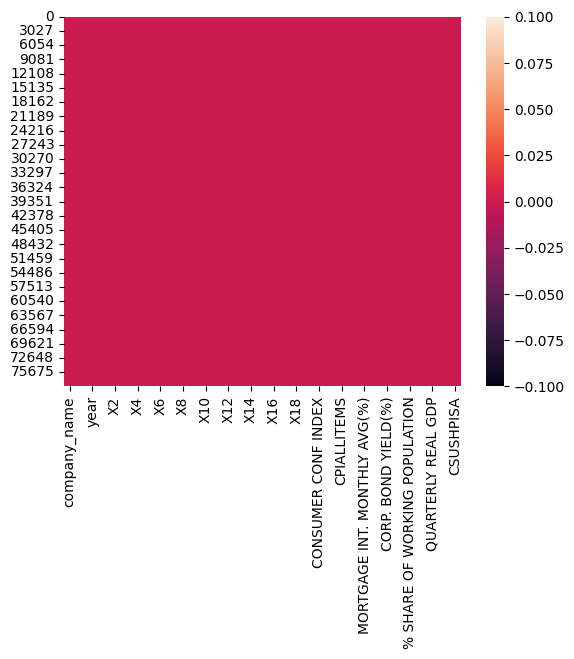

In [21]:
sns.heatmap(df.isna())

# Data Preprocessing

## 1. Encodage de la Variable Cible

In [29]:
data['status_label'].unique()

array(['alive', 'failed'], dtype=object)

In [30]:
for col in df.select_dtypes('object'):
  print(col,df[col].unique)

company_name <bound method Series.unique of 0           C_1
1           C_1
2           C_1
3           C_1
4           C_1
          ...  
78677    C_8971
78678    C_8971
78679    C_8971
78680    C_8971
78681    C_8971
Name: company_name, Length: 78682, dtype: object>


### target (status_label): 
* 0: alive
* 1: failed (la classe la plus risquée qui nous intéresse)

### A exécuter une seule fois pour éviter d'obtenir des NaN

In [55]:
df['status_label'] = data['status_label'].values

In [56]:
df

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,INFLATION(%),MORTGAGE INT. MONTHLY AVG(%),MED HOUSEHOLD INCOME,CORP. BOND YIELD(%),MONTHLY HOME SUPPLY,% SHARE OF WORKING POPULATION,GDP PER CAPITA,QUARTERLY REAL GDP,QUARTERLY GDP GROWTH RATE (%),CSUSHPISA
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,2.180000,7.440000,40700.0,7.041667,4.091667,66.200000,35250.000,13543.77400,4.700000,93.400000
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,3.380000,8.053462,41990.0,7.622500,4.233333,66.500000,36320.000,14096.03300,4.100000,104.800000
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,2.830000,6.967885,42230.0,7.082500,4.050000,66.400000,37130.000,14230.72600,1.000000,113.200000
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,1.704039,6.318938,42409.0,6.408750,4.037500,66.593595,38104.875,13524.77475,0.354195,288.492750
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,2.272269,5.819542,43318.0,5.666667,3.908333,66.739214,39418.500,13865.51925,1.057761,249.061250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78677,C_8971,alive,2014,233.211,43.338,14.094,45.615,3.376,25.261,22.846,...,1.621905,4.172833,53657.0,4.162500,5.475000,66.317699,54913.000,16932.05175,0.636994,146.101750
78678,C_8971,alive,2015,105.559,59.184,42.592,202.133,2.288,129.688,54.611,...,0.118885,3.849000,56516.0,3.886667,5.166667,66.113878,56520.000,17390.29525,0.465731,150.558917
78679,C_8971,alive,2016,63.971,69.074,65.057,79.051,2.581,-1.442,42.467,...,1.261844,3.647708,59039.0,3.665833,5.208333,65.880715,57591.500,17680.27375,0.497393,168.893167
78680,C_8971,alive,2017,135.207,66.527,65.330,69.171,2.013,-20.401,27.217,...,2.131615,3.991000,61136.0,3.743333,5.383333,65.623251,59595.000,18079.08400,0.672811,181.989250


In [57]:
df['status_label'] = df['status_label'].str.strip().str.lower().map({'alive': 0, 'failed': 1})

In [58]:
df

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,INFLATION(%),MORTGAGE INT. MONTHLY AVG(%),MED HOUSEHOLD INCOME,CORP. BOND YIELD(%),MONTHLY HOME SUPPLY,% SHARE OF WORKING POPULATION,GDP PER CAPITA,QUARTERLY REAL GDP,QUARTERLY GDP GROWTH RATE (%),CSUSHPISA
0,C_1,0,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,2.180000,7.440000,40700.0,7.041667,4.091667,66.200000,35250.000,13543.77400,4.700000,93.400000
1,C_1,0,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,3.380000,8.053462,41990.0,7.622500,4.233333,66.500000,36320.000,14096.03300,4.100000,104.800000
2,C_1,0,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,2.830000,6.967885,42230.0,7.082500,4.050000,66.400000,37130.000,14230.72600,1.000000,113.200000
3,C_1,0,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,1.704039,6.318938,42409.0,6.408750,4.037500,66.593595,38104.875,13524.77475,0.354195,288.492750
4,C_1,0,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,2.272269,5.819542,43318.0,5.666667,3.908333,66.739214,39418.500,13865.51925,1.057761,249.061250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78677,C_8971,0,2014,233.211,43.338,14.094,45.615,3.376,25.261,22.846,...,1.621905,4.172833,53657.0,4.162500,5.475000,66.317699,54913.000,16932.05175,0.636994,146.101750
78678,C_8971,0,2015,105.559,59.184,42.592,202.133,2.288,129.688,54.611,...,0.118885,3.849000,56516.0,3.886667,5.166667,66.113878,56520.000,17390.29525,0.465731,150.558917
78679,C_8971,0,2016,63.971,69.074,65.057,79.051,2.581,-1.442,42.467,...,1.261844,3.647708,59039.0,3.665833,5.208333,65.880715,57591.500,17680.27375,0.497393,168.893167
78680,C_8971,0,2017,135.207,66.527,65.330,69.171,2.013,-20.401,27.217,...,2.131615,3.991000,61136.0,3.743333,5.383333,65.623251,59595.000,18079.08400,0.672811,181.989250


## 2. Diagnostic des Outliers (Méthode IQR) 

In [59]:
# Identifier les colonnes financières
features_comptables = [f'X{i}' for i in range(1, 19)]

print("Diagnostic des Outliers (Méthode IQR) :")
for col in features_comptables:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Définition des bornes (règle standard : 1.5 * IQR)
        borne_inf = Q1 - 1.5 * IQR
        borne_sup = Q3 + 1.5 * IQR
        
        nb_outliers = df[(df[col] < borne_inf) | (df[col] > borne_sup)].shape[0]
        if nb_outliers > 0:
            print(f"{col} : {nb_outliers} valeurs extrêmes détectées.")

Diagnostic des Outliers (Méthode IQR) :
X1 : 10975 valeurs extrêmes détectées.
X2 : 11594 valeurs extrêmes détectées.
X3 : 11475 valeurs extrêmes détectées.
X4 : 12218 valeurs extrêmes détectées.
X5 : 12435 valeurs extrêmes détectées.
X6 : 17004 valeurs extrêmes détectées.
X7 : 11237 valeurs extrêmes détectées.
X8 : 11409 valeurs extrêmes détectées.
X9 : 11225 valeurs extrêmes détectées.
X10 : 11521 valeurs extrêmes détectées.
X11 : 12641 valeurs extrêmes détectées.
X12 : 13251 valeurs extrêmes détectées.
X13 : 11306 valeurs extrêmes détectées.
X14 : 11781 valeurs extrêmes détectées.
X15 : 17867 valeurs extrêmes détectées.
X16 : 11225 valeurs extrêmes détectées.
X17 : 12366 valeurs extrêmes détectées.
X18 : 11214 valeurs extrêmes détectées.


### Application de la Winsorisation (Plafonnement 1% - 99%)


In [62]:
for col in features_comptables:
    if col in df.columns:
        # Calcul des percentiles
        low = df[col].quantile(0.01)
        high = df[col].quantile(0.99)
        
        # Remplacement des valeurs extrêmes par les bornes
        df[col] = np.clip(df[col], low, high)

print(" Traitement terminé : Les ratios financiers sont désormais stabilisés.")

 Traitement terminé : Les ratios financiers sont désormais stabilisés.


Visualisation des distributions des ratios financiers...


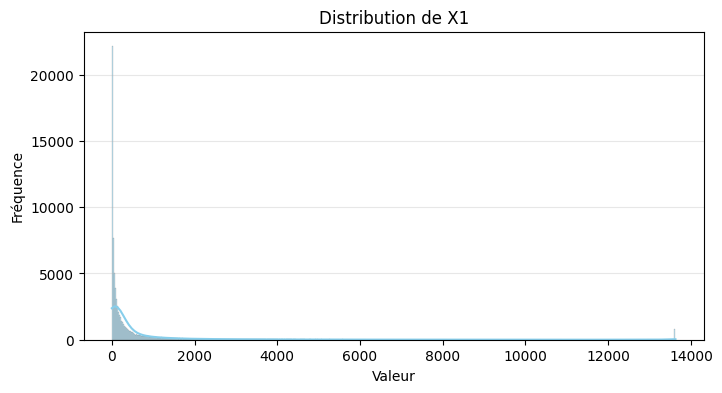

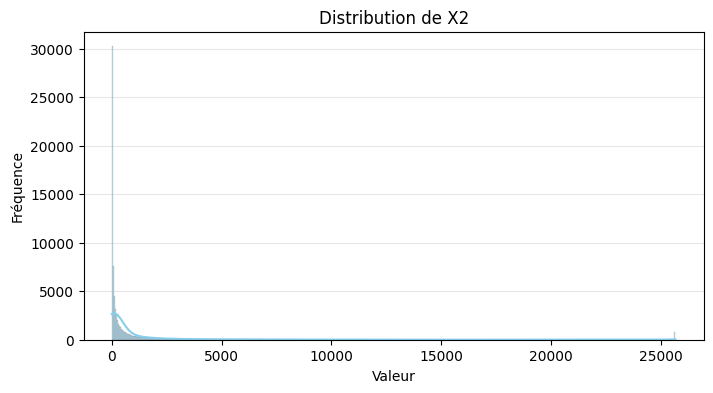

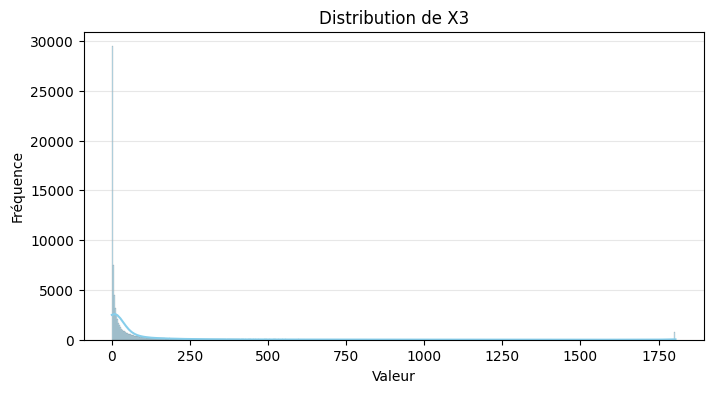

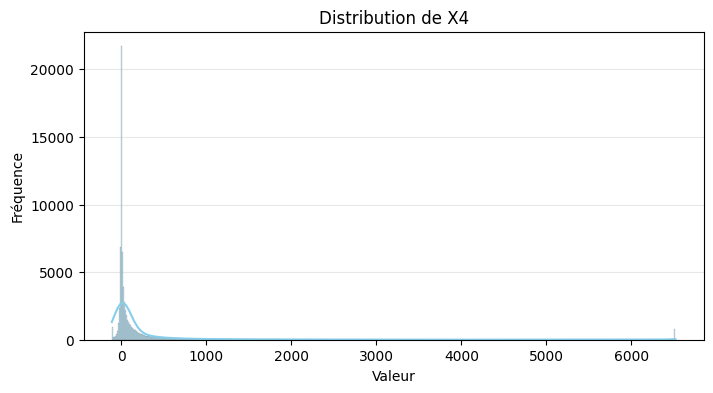

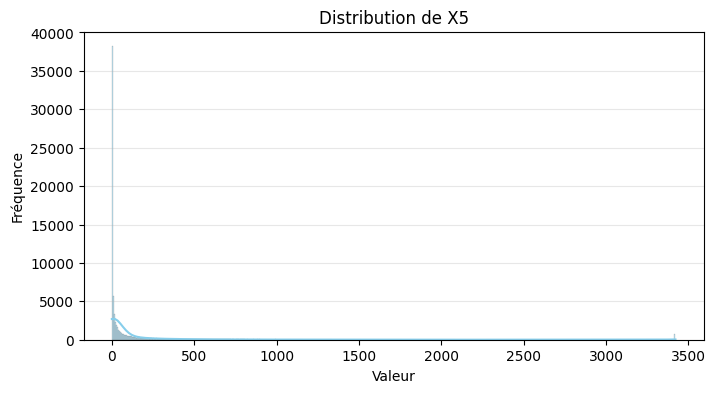

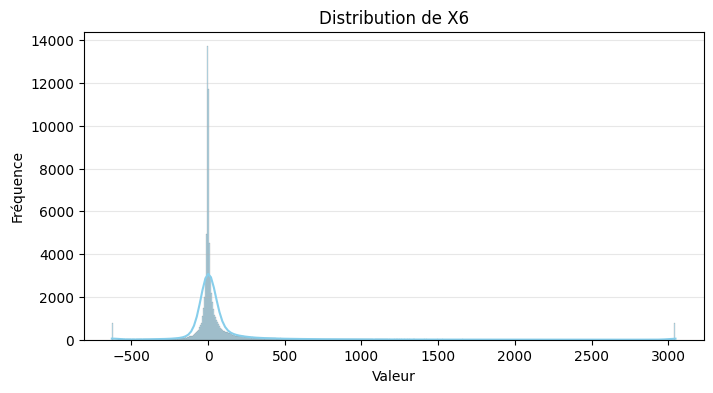

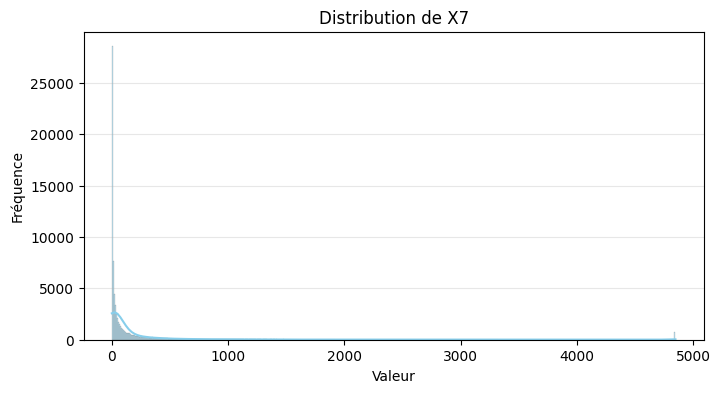

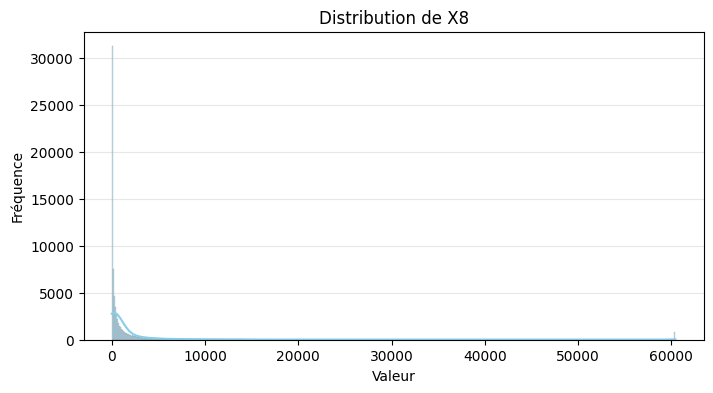

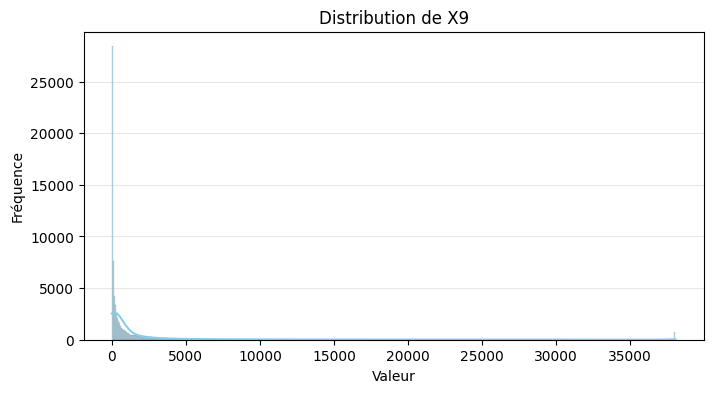

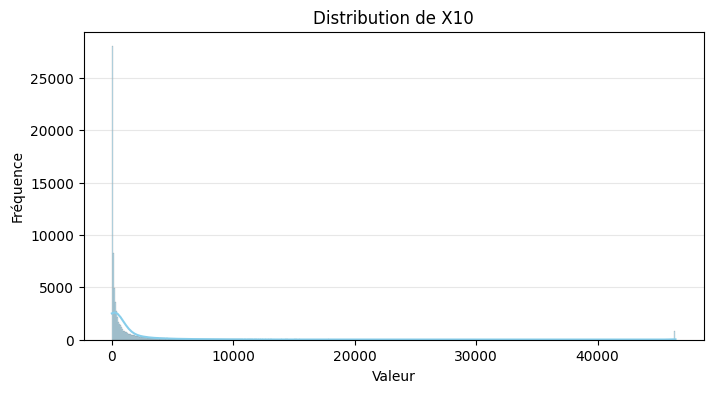

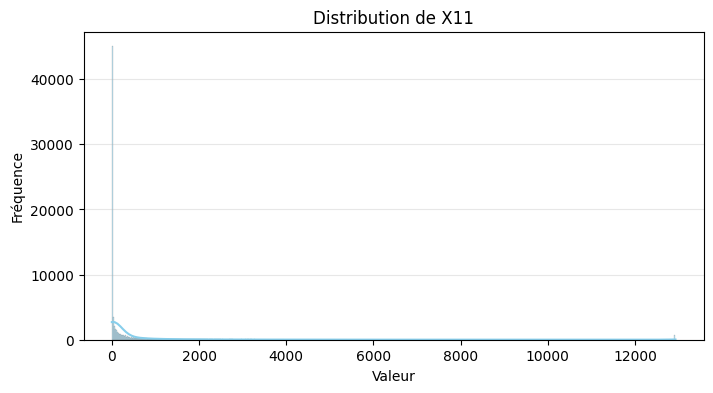

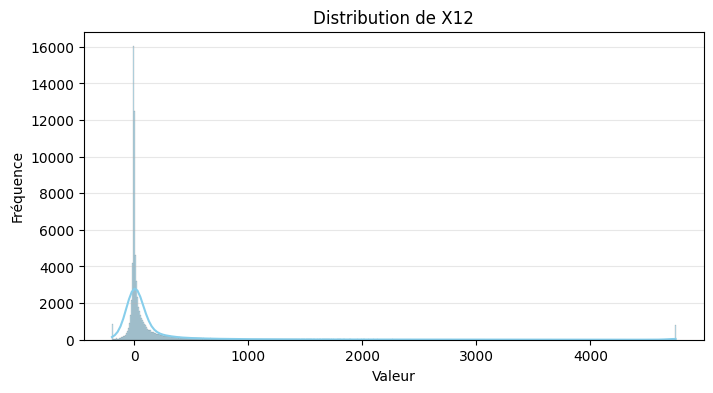

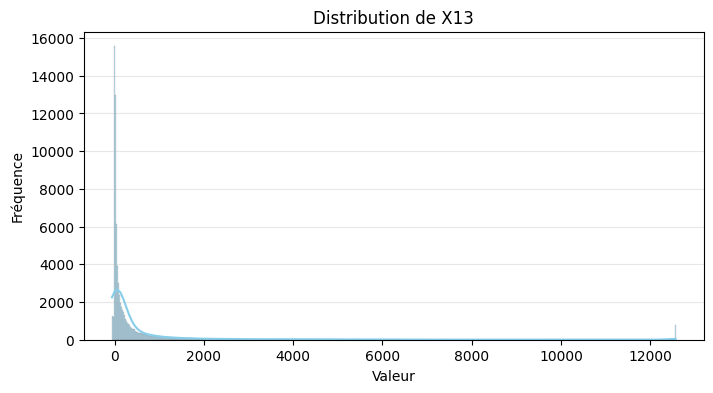

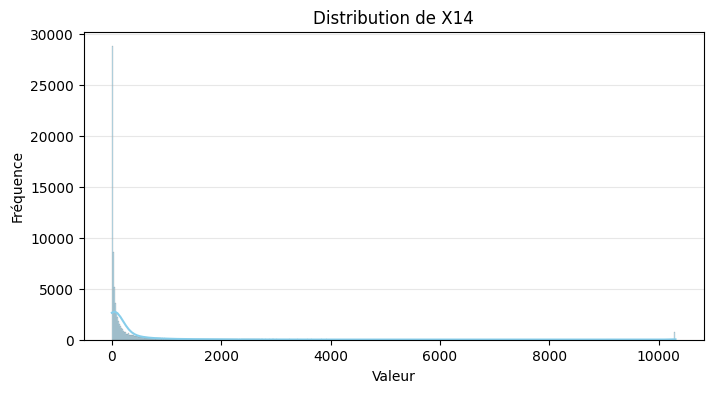

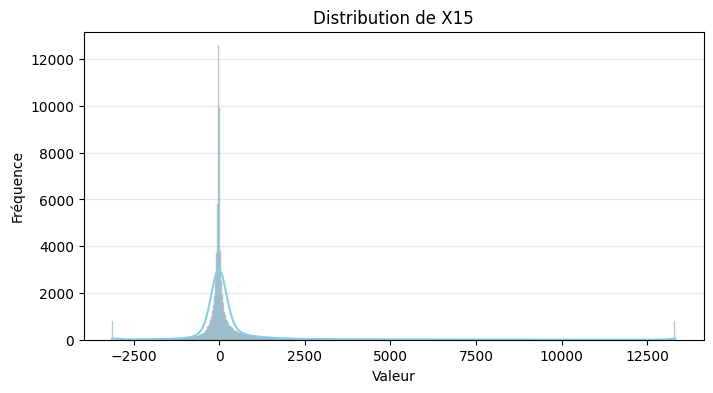

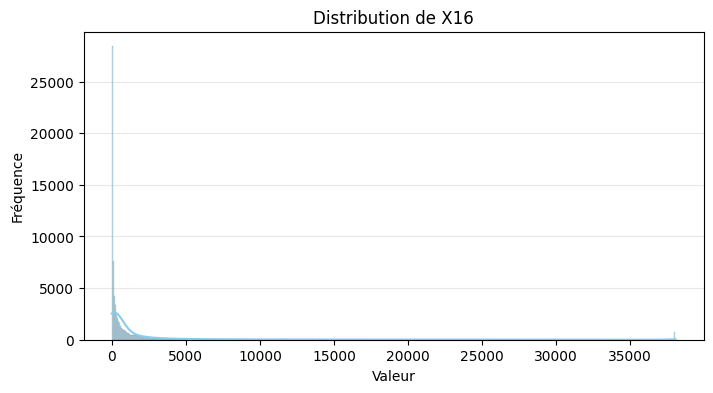

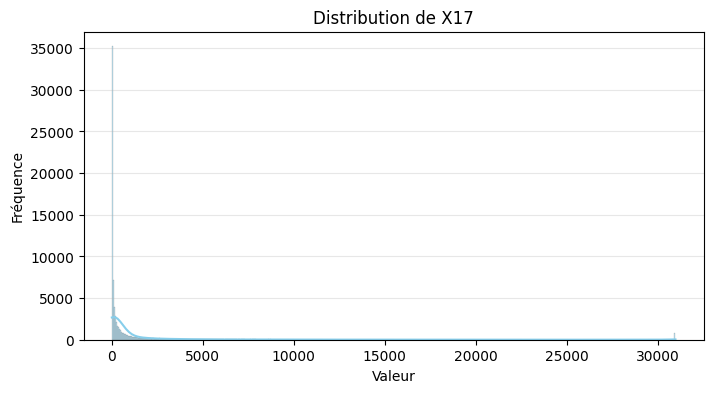

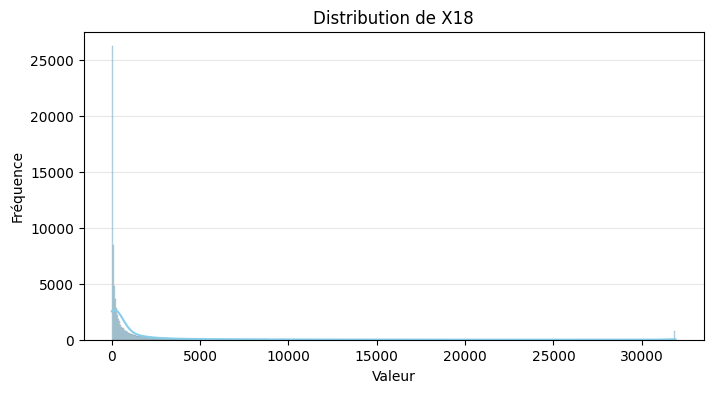

In [63]:
features_to_plot = [col for col in df.columns if col.startswith('X')]

print("Visualisation des distributions des ratios financiers...")

for col in features_to_plot:
    plt.figure(figsize=(8, 4))
    # Utilisation de histplot avec kde=True pour la courbe de densité
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution de {col}')
    plt.xlabel('Valeur')
    plt.ylabel('Fréquence')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

### Explication: on observe que l'immense majorité des entreprises est regroupée au début, et une toute petite poignée (les géants comme apple ..) s'étire vers des chiffres astronomiques. C'est une distribution fortement asymétrique à droite ----> standarisation obligatoire

In [66]:
featuers_columns=[col for col in data.columns if col.startswith('X')]

## 3. Feature Selection

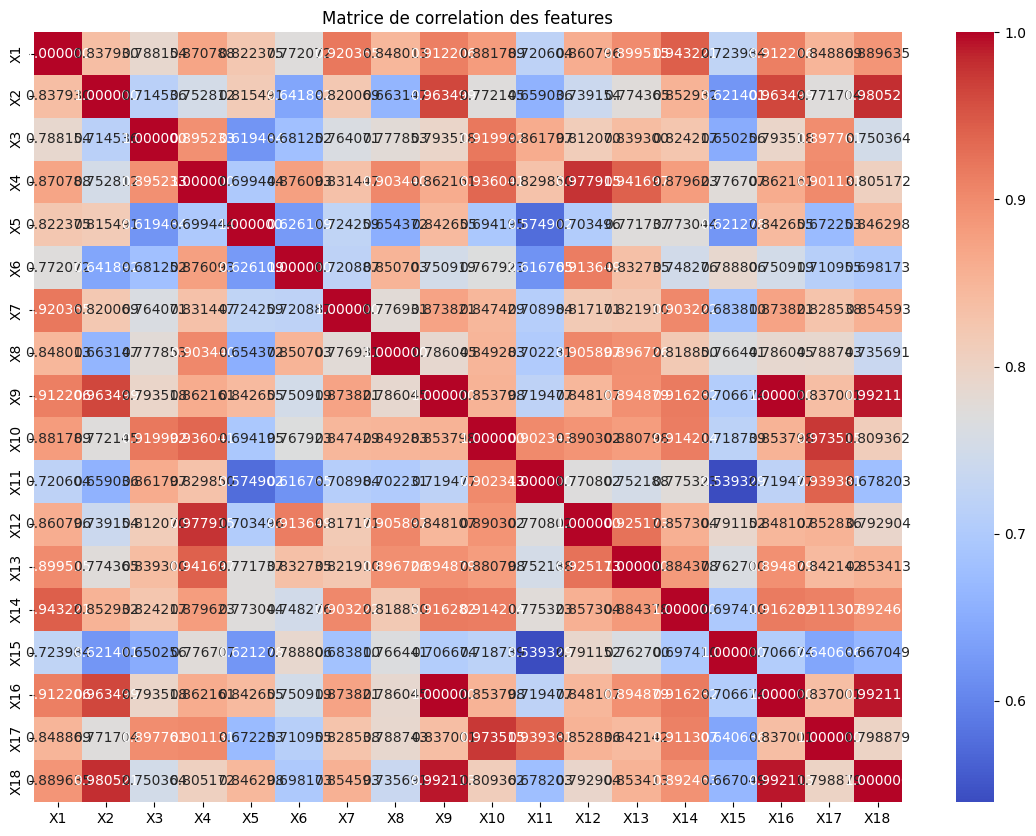

In [65]:
plt.figure(figsize=(14,10))
sns.heatmap(df[featuers_columns].corr(),annot=True,cmap='coolwarm',fmt='2f')
plt.title('Matrice de correlation des features')
plt.show()

### On observe que X16 et X18 sont redondantes avec X9 ---> supprimer les deux variables (Feature Redundancy)

In [67]:
cols_to_drop = ['X16', 'X18']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f"Variables supprimées avec succès : {cols_to_drop}")
else:
    print("Les colonnes sont déjà supprimées.")

# Mise à jour de votre liste de features comptables
features_comptables = [f'X{i}' for i in range(1, 19) if f'X{i}' not in cols_to_drop]

Variables supprimées avec succès : ['X16', 'X18']


In [68]:
features_comptables

['X1',
 'X2',
 'X3',
 'X4',
 'X5',
 'X6',
 'X7',
 'X8',
 'X9',
 'X10',
 'X11',
 'X12',
 'X13',
 'X14',
 'X15',
 'X17']

## 4. Train-Test Split: Découpage Groupé par Entreprise

In [69]:
X=df.drop(['status_label', 'company_name'],axis=1)
y=df['status_label']

In [70]:
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df['company_name']))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [71]:
print(f"Nombre d'entreprises uniques dans le Train : {df.iloc[train_idx]['company_name'].nunique()}")
print(f"Nombre d'entreprises uniques dans le Test : {df.iloc[test_idx]['company_name'].nunique()}")

Nombre d'entreprises uniques dans le Train : 7176
Nombre d'entreprises uniques dans le Test : 1795


## 5. Standardisation des variables (RobustScaler)

In [73]:
data['status_label'].value_counts(normalize=True) # 

status_label
alive     0.933657
failed    0.066343
Name: proportion, dtype: float64

## 6. Handle Data imbalance 

#### SMOTE 
Notre dataset présente un fort déséquilibre de classes (93,4% contre 6,6%). Pour y remédier, nous avons envisagé la méthode SMOTE, qui génère de nouveaux exemples synthétiques à partir de la classe minoritaire : elle identifie les voisins les plus proches d'un point, trace un segment entre eux, puis place un nouvel exemple à une position aléatoire sur ce segment.

Cependant, cette approche se limite aux modèles classiques tels que XGBoost. Elle n'est pas adaptée aux modèles séquentiels comme le LSTM, car elle ne respecte pas la cohérence temporelle des données : les indicateurs financiers d'une entreprise en 2024 doivent être compatibles avec ceux de 2023. Or, SMOTE pourrait générer une entreprise hybride entre deux entités distinctes, produisant ainsi une trajectoire d'évolution qui n'a jamais existé dans la réalité.

In [74]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("Application du SMOTE sur le Train...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Nouvelles dimensions : {X_train_resampled.shape}")

Application du SMOTE sur le Train...
Nouvelles dimensions : (117890, 31)


# XGBoost + Smote (entrainement, évaluation, optimisation)

In [75]:
# Initialisation du modèle
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

# Entraînement
xgb_model.fit(X_train_resampled, y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

Evaluation de notre premier modele

In [76]:
# Prédictions
y_pred = xgb_model.predict(X_test_scaled)

# Rapport de performance
print("\nRésultats XGBoost (avec SMOTE) :")
print(classification_report(y_test, y_pred))


Résultats XGBoost (avec SMOTE) :
              precision    recall  f1-score   support

           0       0.95      0.73      0.82     14517
           1       0.14      0.55      0.22      1177

    accuracy                           0.71     15694
   macro avg       0.55      0.64      0.52     15694
weighted avg       0.89      0.71      0.78     15694



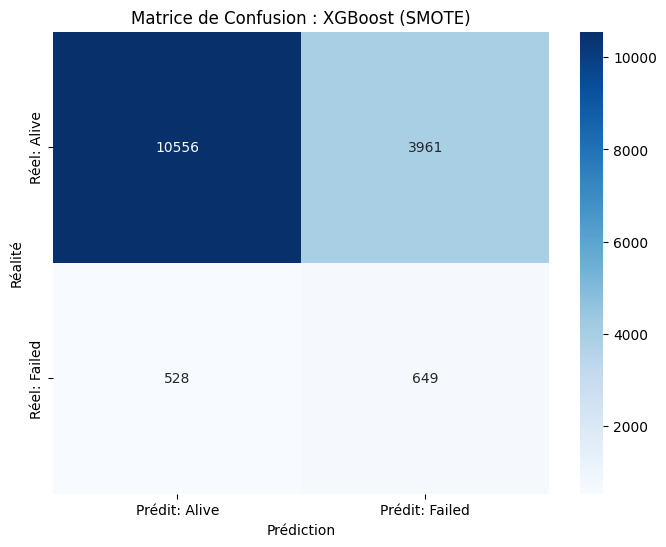

In [77]:
cm = confusion_matrix(y_test, y_pred)

# 2. Visualisation
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prédit: Alive', 'Prédit: Failed'], 
            yticklabels=['Réel: Alive', 'Réel: Failed'])
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.title('Matrice de Confusion : XGBoost (SMOTE)')
plt.show()

In [78]:
# 1. On calcule le ratio entre les deux classes
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 2. On passe ce ratio au modèle
model_pondere = XGBClassifier(
    scale_pos_weight=ratio, 
    n_estimators=100, 
    random_state=42
)

# 3. On entraîne sur les données RÉELLES uniquement
model_pondere.fit(X_train_scaled, y_train)

# 4. On compare les résultats
y_pred_pondere = model_pondere.predict(X_test_scaled)
print(classification_report(y_test, y_pred_pondere))

              precision    recall  f1-score   support

           0       0.94      0.87      0.91     14517
           1       0.19      0.36      0.25      1177

    accuracy                           0.84     15694
   macro avg       0.57      0.62      0.58     15694
weighted avg       0.89      0.84      0.86     15694



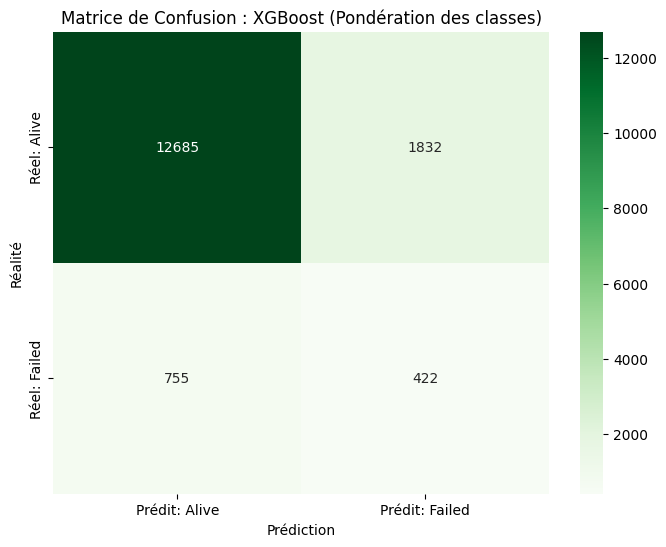

In [79]:
# 1. Calcul de la matrice avec les prédictions pondérées
cm_pondere = confusion_matrix(y_test, y_pred_pondere)

# 2. Visualisation
plt.figure(figsize=(8, 6))
sns.heatmap(cm_pondere, annot=True, fmt='d', cmap='Greens', # 'Greens' pour changer de couleur
            xticklabels=['Prédit: Alive', 'Prédit: Failed'], 
            yticklabels=['Réel: Alive', 'Réel: Failed'])
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.title('Matrice de Confusion : XGBoost (Pondération des classes)')
plt.show()

In [80]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
# 1. Configuration (5 plis pour une validation robuste)
# on utiliser TimeSeriesSplit puisque ona la notion d'ordre temporel
tscv = TimeSeriesSplit(n_splits=5)

# On suppose que 'model_pondere' est déjà défini avec scale_pos_weight
scores = cross_val_score(model_pondere, X_train_scaled, y_train, cv=tscv, scoring='f1')

# 3. Analyse des résultats
print(f"Scores F1 sur chaque bloc : {scores}")
print(f"Moyenne de précision du modèle : {np.mean(scores):.4f}")
print(f"Stabilité (écart-type) : {np.std(scores):.4f}")

Scores F1 sur chaque bloc : [0.14843007 0.13441296 0.12327947 0.1563745  0.2574605 ]
Moyenne de précision du modèle : 0.1640
Stabilité (écart-type) : 0.0481


# Analyse Temporelle Spécifique (Préparation au LSTM)

### Notre objectif est d'exploiter un modèle LSTM, adapté aux données séquentielles temporelles. 
### Cependant, avant toute modélisation, il est nécessaire de vérifier la structure temporelle du dataset en répondant à deux questions clés :

1. Combien d'années d'historique sont disponibles par entreprise ?
2. La distribution des faillites varie-t-elle selon les années ?


count    8971.000000
mean        8.770706
std         6.421565
min         1.000000
25%         3.000000
50%         7.000000
75%        14.000000
max        20.000000
Name: year, dtype: float64


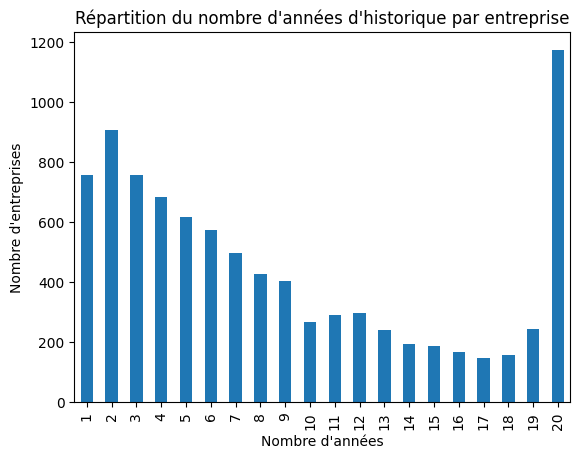

In [81]:
years_company=df.groupby('company_name')['year'].count()
print(years_company.describe())

import matplotlib.pyplot as plt
years_company.value_counts().sort_index().plot(kind='bar')
plt.title("Répartition du nombre d'années d'historique par entreprise")
plt.xlabel("Nombre d'années")
plt.ylabel("Nombre d'entreprises")
plt.show()


### Le premier quartile indique que 25% des entreprises disposent d'un historique allant de 1 à 3 ans. Cela signifie que 75% des entreprises possèdent déjà au moins 3 ans d'historique, ce qui confirme que la majorité du dataset présente une couverture temporelle suffisante pour alimenter un modèle séquentiel.

In [91]:
years_per_company=df.groupby('company_name')['year'].transform('count')
data_filtered=data[years_per_company>=3].copy()
print("Nombre de lignes avant filtrage :", len(data))
print("Nombre de lignes après filtrage :", len(data_filtered))
print("Nombre d'entreprises uniques restantes :", data_filtered['company_name'].nunique())

Nombre de lignes avant filtrage : 78682
Nombre de lignes après filtrage : 76115
Nombre d'entreprises uniques restantes : 7310


In [92]:
data_filtered

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78677,C_8971,alive,2014,233.211,43.338,14.094,45.615,3.376,25.261,22.846,...,104.223,1099.101,184.666,31.521,60.885,28.197,28.095,104.223,225.887,58.608
78678,C_8971,alive,2015,105.559,59.184,42.592,202.133,2.288,129.688,54.611,...,291.153,1865.926,770.103,159.541,231.969,88.128,157.783,291.153,880.327,89.020
78679,C_8971,alive,2016,63.971,69.074,65.057,79.051,2.581,-1.442,42.467,...,169.858,1746.235,683.985,13.994,100.784,85.765,156.341,169.858,770.233,90.807
78680,C_8971,alive,2017,135.207,66.527,65.330,69.171,2.013,-20.401,27.217,...,161.884,1736.110,694.035,3.841,95.357,82.010,135.941,161.884,776.697,92.713


### Vérifier s'il y a des trous ou des années vides

/tmp/ipykernel_58/2952070537.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_filtered,x='year',palette='viridis')


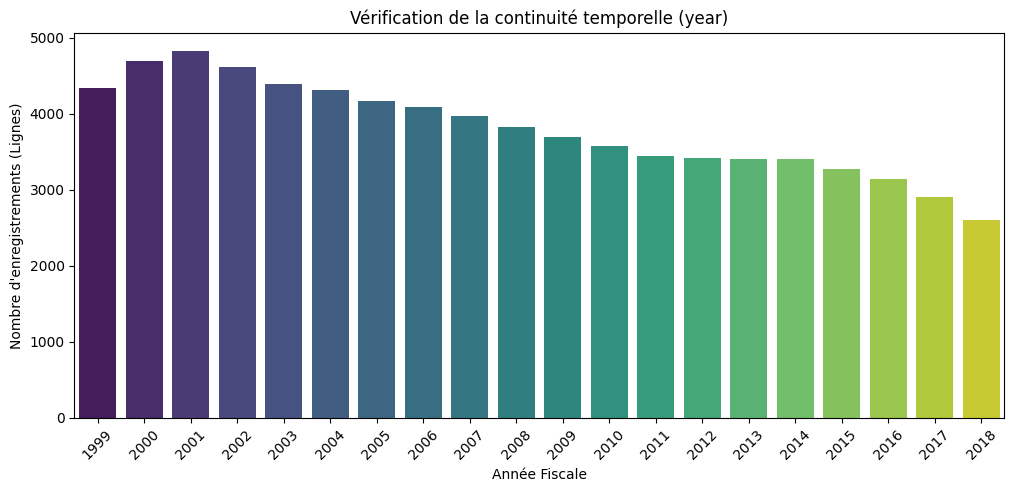

In [93]:
plt.figure(figsize=(12,5))
sns.countplot(data=data_filtered,x='year',palette='viridis')
plt.title('Vérification de la continuité temporelle (year)')
plt.xlabel('Année Fiscale')
plt.ylabel("Nombre d'enregistrements (Lignes)")
plt.xticks(rotation=45)
plt.show()

### Transformer status_label en chiffres (0 et 1)
### A exécuter une seule fois, sinon on risque d'avoir NaN dans status_label


In [95]:
data_filtered['status_label']=data_filtered['status_label'].map({'alive':0,'failed':1})

In [100]:
data_filtered

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,0,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,0,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,0,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,0,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,0,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78677,C_8971,0,2014,233.211,43.338,14.094,45.615,3.376,25.261,22.846,...,104.223,1099.101,184.666,31.521,60.885,28.197,28.095,104.223,225.887,58.608
78678,C_8971,0,2015,105.559,59.184,42.592,202.133,2.288,129.688,54.611,...,291.153,1865.926,770.103,159.541,231.969,88.128,157.783,291.153,880.327,89.020
78679,C_8971,0,2016,63.971,69.074,65.057,79.051,2.581,-1.442,42.467,...,169.858,1746.235,683.985,13.994,100.784,85.765,156.341,169.858,770.233,90.807
78680,C_8971,0,2017,135.207,66.527,65.330,69.171,2.013,-20.401,27.217,...,161.884,1736.110,694.035,3.841,95.357,82.010,135.941,161.884,776.697,92.713


# LSTM

## Création des séquences
Pour alimenter le modèle LSTM, nous transformons les données tabulaires en séquences temporelles. Chaque séquence représente l'historique financier d'une entreprise sur une fenêtre glissante de 3 ans, ce qui est cohérent avec la structure temporelle observée précédemment. Le modèle prend ainsi en entrée une succession d'états financiers annuels et apprend à détecter les patterns caractéristiques d'une trajectoire menant à la faillite.

In [103]:
import pickle
import numpy as np
from sklearn.preprocessing import RobustScaler

# ─── 1. Fonction create_lstm_sequences ───
def create_lstm_sequences(df, time_steps=3):
    X, Y = [], []
    feature_cols = [col for col in df.columns 
                    if col.startswith('X') or col.startswith('Div_')]
    for company, group in df.groupby('company_name'):
        group = group.sort_values('year')
        years    = group['year'].values
        features = group[feature_cols].values
        labels   = group['status_label'].values
        for i in range(len(group) - time_steps):
            if years[i + time_steps] == years[i] + time_steps:
                X.append(features[i : i + time_steps])
                Y.append(labels[i + time_steps])
    return np.array(X), np.array(Y)

# ─── 2. Split par entreprise ───
companies = data_filtered['company_name'].unique()
np.random.seed(42)
np.random.shuffle(companies)  # ← shuffle pour éviter biais

n = len(companies)
train_cos = companies[:int(n * 0.70)]
val_cos   = companies[int(n * 0.70):int(n * 0.85)]
test_cos  = companies[int(n * 0.85):]

df_train = data_filtered[data_filtered['company_name'].isin(train_cos)].copy()
df_val   = data_filtered[data_filtered['company_name'].isin(val_cos)].copy()
df_test  = data_filtered[data_filtered['company_name'].isin(test_cos)].copy()

print(f"Entreprises train : {len(train_cos)}")
print(f"Entreprises val   : {len(val_cos)}")
print(f"Entreprises test  : {len(test_cos)}")

# ─── 3. Normalisation ───
feature_cols = [col for col in data_filtered.columns 
                if col.startswith('X') or col.startswith('Div_')]

scaler = RobustScaler()
df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
df_val[feature_cols]   = scaler.transform(df_val[feature_cols])
df_test[feature_cols]  = scaler.transform(df_test[feature_cols])

# Sauvegarder le scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# ─── 4. Séquences ───
X_train_seq, y_train_seq = create_lstm_sequences(df_train, time_steps=3)
X_val_seq,   y_val_seq   = create_lstm_sequences(df_val,   time_steps=3)
X_test_seq,  y_test_seq  = create_lstm_sequences(df_test,  time_steps=3)

print(f"X_train_seq : {X_train_seq.shape}")
print(f"X_val_seq   : {X_val_seq.shape}")
print(f"X_test_seq  : {X_test_seq.shape}")



Entreprises train : 5117
Entreprises val   : 1096
Entreprises test  : 1097
X_train_seq : (36765, 3, 18)
X_val_seq   : (8419, 3, 18)
X_test_seq  : (7507, 3, 18)


## Choix de l'architecture 
On commence tjrs par une archi simple et efficace( 1 couche LSTM,couche dropout ,couche dense)

In [98]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf

model = Sequential([
    LSTM(32, 
         input_shape=(3, X_train_seq.shape[2]), 
         return_sequences=False),
    Dropout(0.5),
    Dense(32, activation='relu'),  # ← couche dense intermédiaire
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

model.summary()

2026-06-07 17:29:31.260987: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780853371.699454      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780853371.820463      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780853372.851423      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780853372.851470      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780853372.851474      58 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,617 (29.75 KB)

 Trainable params: 7,617 (29.75 KB)

 Non-trainable params: 0 (0.00 B)

## Entrainement

In [105]:
from sklearn.utils.class_weight import compute_class_weight

# 1. Calculer automatiquement le déséquilibre des classes
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_seq),
    y=y_train_seq  
)
class_weight_dict = {0: weights[0], 1: weights[1]}
print("Poids appliqués pour équilibrer :", class_weight_dict)

# 2. Entraînement
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=15,
    batch_size=64,
    class_weight=class_weight_dict,
    verbose=1
)

Poids appliqués pour équilibrer : {0: np.float64(0.5358392117996852), 1: np.float64(7.475599837332249)}
Epoch 1/15
575/575 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6961 - auc: 0.8085 - loss: 0.5240 - precision: 0.1489 - recall: 0.7515 - val_accuracy: 0.6536 - val_auc: 0.7240 - val_loss: 0.5976 - val_precision: 0.0957 - val_recall: 0.6806
Epoch 2/15
575/575 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6887 - auc: 0.8109 - loss: 0.5217 - precision: 0.1482 - recall: 0.7698 - val_accuracy: 0.6647 - val_auc: 0.7242 - val_loss: 0.5818 - val_precision: 0.0946 - val_recall: 0.6458
Epoch 3/15
575/575 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6895 - auc: 0.8135 - loss: 0.5172 - precision: 0.1503 - recall: 0.7828 - val_accuracy: 0.6722 - val_auc: 0.7164 - val_loss: 0.5646 - val_precision: 0.0970 - val_recall: 0.6481
Epoch 4/15
575/575 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6965 - auc: 0.8171 - loss: 0.5145 - precision: 0.1526 - recall: 0.7767 - val_accuracy: 0.7432 - val_auc:

## Evaluation

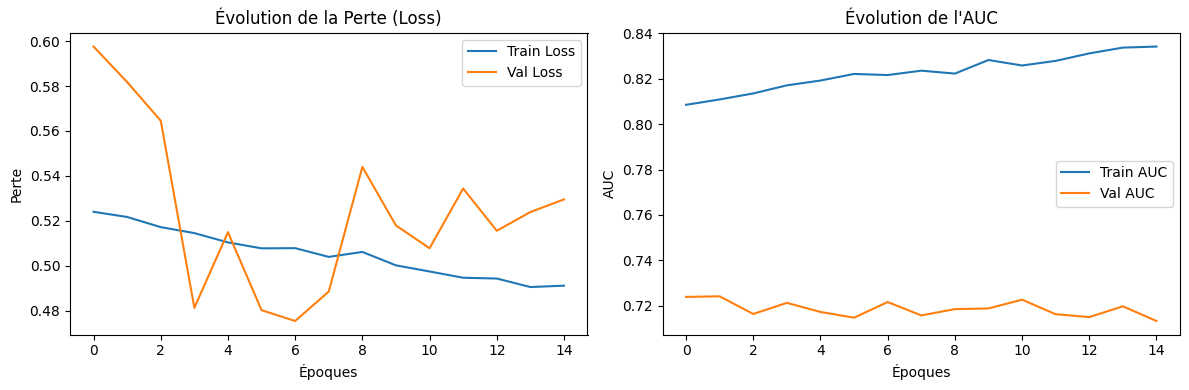

In [106]:
# 1. Graphique de la Perte (Loss)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Évolution de la Perte (Loss)')
plt.xlabel('Époques')
plt.ylabel('Perte')
plt.legend()

# 2. Graphique de l'AUC
plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.title('Évolution de l\'AUC')
plt.xlabel('Époques')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


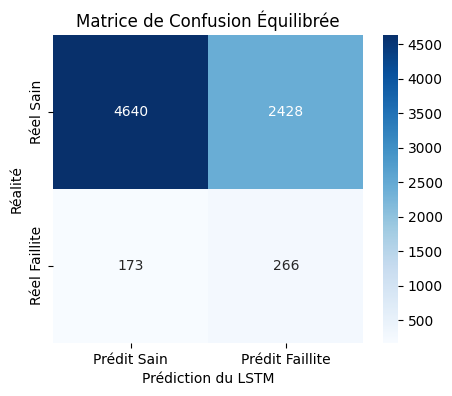

              precision    recall  f1-score   support

           0       0.96      0.66      0.78      7068
           1       0.10      0.61      0.17       439

    accuracy                           0.65      7507
   macro avg       0.53      0.63      0.48      7507
weighted avg       0.91      0.65      0.75      7507



In [107]:
# 1. Prédictions sur le jeu de test
y_pred_probs = model.predict(X_test_seq)       
y_pred = (y_pred_probs > 0.5).astype(int)

# 2. Calcul de la matrice
cm = confusion_matrix(y_test_seq, y_pred)         
# 3. Affichage graphique
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit Sain', 'Prédit Faillite'],
            yticklabels=['Réel Sain', 'Réel Faillite'])
plt.title('Matrice de Confusion Équilibrée')
plt.ylabel('Réalité')
plt.xlabel('Prédiction du LSTM')
plt.show()

# 4. Rapport complet
print(classification_report(y_test_seq, y_pred))  

## Enregistrement du modèle

In [109]:
model.save('modele_lstm.keras')
print("Modèle enregistré avec succès !")

Modèle enregistré avec succès !
